In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde, boxcox
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('factsales.csv')
df.head()

,SalesID,OrderID,ProductID,CustomerID,DateID,GeographyID,Sales,Quantity,Discount,Profit,Market,ShipMode,Discount Category
0,1200,CA-2011-169642,OFF-ST-10002574,BB-10990,447,27,276.28,2,0.0,0.0,US,Second Class,Non-Discounted
1,1486,CA-2012-142993,OFF-ST-10000934,KA-16525,555,48,81.96,2,0.0,0.0,US,Standard Class,Non-Discounted
2,1501,CA-2012-130736,OFF-FA-10003467,JF-15490,705,48,3.96,2,0.0,0.0,US,First Class,Non-Discounted
3,2167,CA-2011-136567,OFF-ST-10004337,PS-19045,17,105,122.48,2,0.0,0.0,US,First Class,Non-Discounted
4,5202,AG-2011-4560,FUR-DEF-10000572,EG-3900,17,805,103.92,2,0.0,0.0,Africa,Standard Class,Non-Discounted


In [4]:
df.columns

Index(['SalesID', 'OrderID', 'ProductID', 'CustomerID', 'DateID',
       'GeographyID', 'Sales', 'Quantity', 'Discount', 'Profit', 'Market',
       'ShipMode', 'Discount Category'],
      dtype='object')

In [5]:
df.Quantity.value_counts()

2     14427
3     11220
1      9560
4      7162
5      5649
6      3404
7      2807
8      1538
9      1109
10      317
14      206
12      188
11      185
13       98
Name: Quantity, dtype: int64

In [6]:
df.shape

(57870, 13)

In [7]:
df['Discount Category'].value_counts()

Non-Discounted    33540
Discounted        24330
Name: Discount Category, dtype: int64

In [8]:
df_q = df[['Quantity', 'Discount Category']]
df_q.describe()

,Quantity
count,57870.000000
mean,3.506895
std,2.272327
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,14.000000


In [9]:
q1, q3 = df_q.Quantity.quantile([0.25, 0.75])
iqr = q3 - q1
lower_lim = q1 - 1.5 * iqr
upper_lim = q3 + 1.5 * iqr
df_q = df_q[(df_q.Quantity > lower_lim) & (df_q.Quantity < upper_lim)]
df_q.describe()

,Quantity
count,56876.000000
mean,3.363897
std,2.005774
min,1.000000
25%,2.000000
50%,3.000000
75%,5.000000
max,9.000000


In [10]:
df_q.Quantity.value_counts()

2    14427
3    11220
1     9560
4     7162
5     5649
6     3404
7     2807
8     1538
9     1109
Name: Quantity, dtype: int64

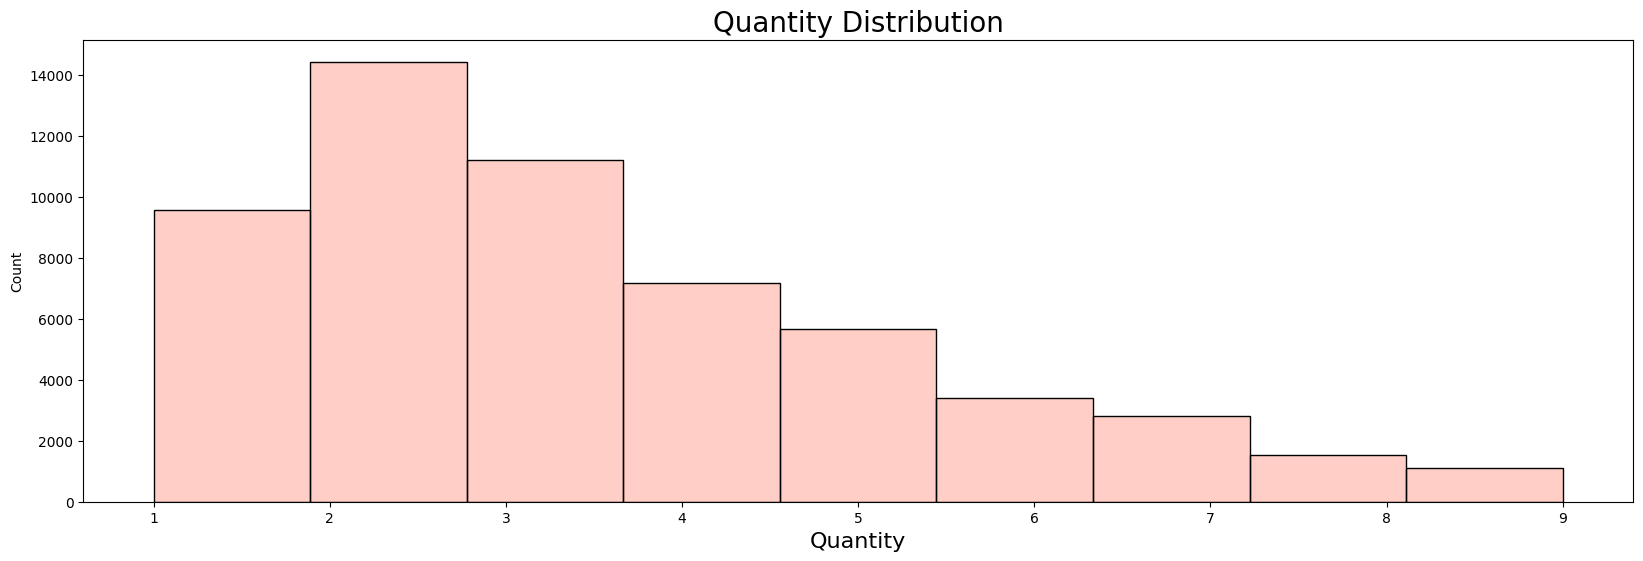

In [11]:
plt.figure(figsize=(20, 6))
sns.histplot(df_q['Quantity'], bins=9, color='tomato', edgecolor='black', alpha=0.3)
plt.title('Quantity Distribution', fontsize=20)
plt.xlabel('Quantity', fontsize=16)
plt.show()

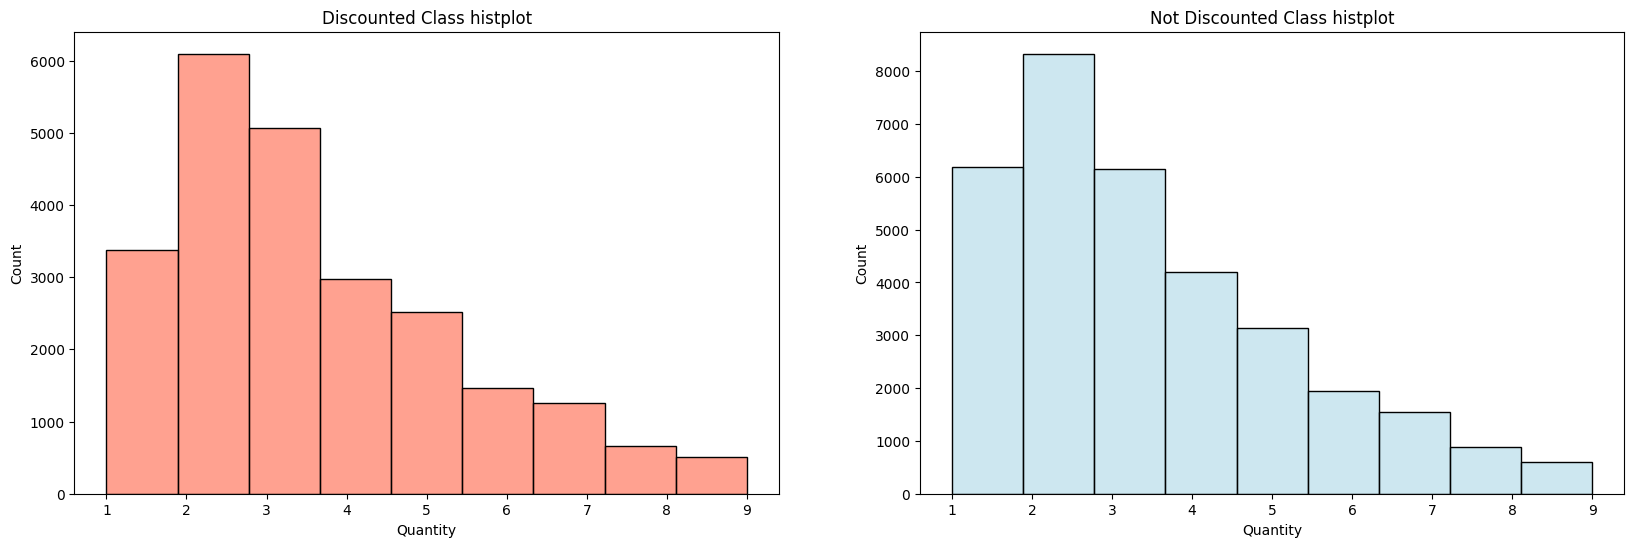

In [12]:
discount = df_q[df_q['Discount Category'] == 'Discounted']['Quantity']
not_discount = df_q[df_q['Discount Category'] == 'Non-Discounted']['Quantity']
fig, ax = plt.subplots(1, 2,  figsize=(20, 6))
sns.histplot(discount, ax=ax[0], bins=9,  color='tomato', alpha=0.6)
sns.histplot(not_discount, ax=ax[1], bins=9, color='lightblue', alpha=0.6)
ax[0].set_title('Discounted Class histplot')
ax[1].set_title('Not Discounted Class histplot')
plt.show()

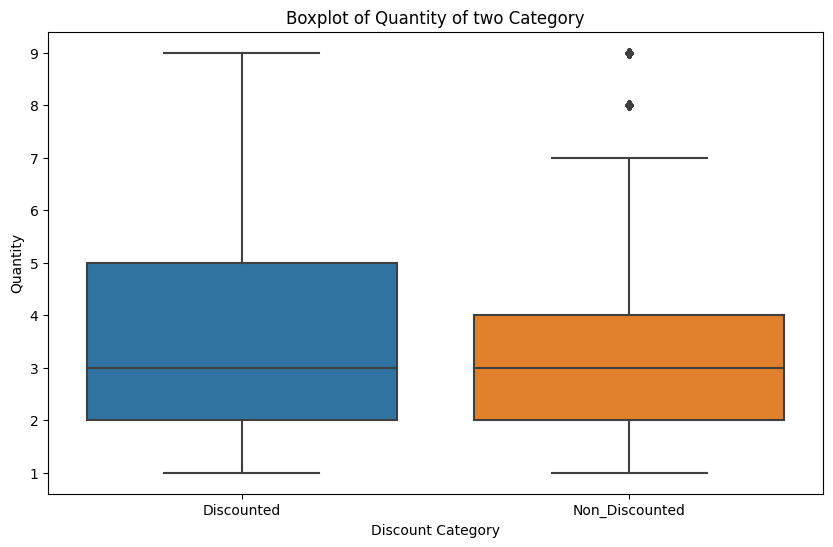

In [13]:
box = pd.DataFrame({
    'Quantity': pd.concat([discount, not_discount], axis=0),
    'Discount Category': ['Discounted']*len(discount) + ['Non_Discounted']*len(not_discount)
})
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(y='Quantity', x='Discount Category', data=box, ax=ax)
plt.title('Boxplot of Quantity of two Category')
plt.show()

In [14]:
#Shapiro Test
stat1, p1 = stats.shapiro(discount)
stat2, p2 = stats.shapiro(not_discount)
print(f'Discount group: Statistics = {stat1}, p = {p1}')
print(f'Not Discount group: Statistics = {stat2}, p = {p2}')
alpha = 0.05
if p1 > alpha:
    print('Discount sample looks Gaussian')
else:
    print('Discount sample does not look Gaussian')

if p2 > alpha:
    print('Not Discount sample looks Gaussian')
else:
    print('Not Discount sample does not look Gaussian')


Discount group: Statistics = 0.9002221822738647, p = 0.0
Not Discount group: Statistics = 0.8919684290885925, p = 0.0
Discount sample does not look Gaussian
Not Discount sample does not look Gaussian


In [15]:
#Normalize
#Square Root Transformation
discount_sqrt = np.sqrt(discount)
not_discount_sqrt = np.sqrt(not_discount)

stat1, p1 = stats.shapiro(discount_sqrt)
stat2, p2 = stats.shapiro(not_discount_sqrt)

print(f'Sqrt Discount: Statistics = {stat1}, p = {p1}')
print(f'Sqrt Not Discount: Statistics = {stat2}, p = {p2}')


Sqrt Discount: Statistics = 0.9399933218955994, p = 0.0
Sqrt Not Discount: Statistics = 0.9312768578529358, p = 0.0


In [16]:
#Log Transformation
discount_log = np.log1p(discount)
not_discount_log = np.log1p(not_discount)

stat1, p1 = stats.shapiro(discount_log)
stat2, p2 = stats.shapiro(not_discount_log)

print(f'Log Discount: Statistics = {stat1}, p = {p1}')
print(f'Log Not Discount: Statistics = {stat2}, p = {p2}')

Log Discount: Statistics = 0.9431052207946777, p = 0.0
Log Not Discount: Statistics = 0.9341597557067871, p = 0.0


In [17]:
#Box-Cox Transformation
discount_boxcox, lambda_discount = boxcox(discount + 1)  
not_discount_boxcox, lambda_not_discount = boxcox(not_discount + 1)

stat1, p1 = stats.shapiro(discount_boxcox)
stat2, p2 = stats.shapiro(not_discount_boxcox)

print(f'Box-Cox Discount: Statistics = {stat1}, p = {p1}')
print(f'Box-Cox Not Discount: Statistics = {stat2}, p = {p2}')
print(f'Lambda values: Discount = {lambda_discount}, Not Discount = {lambda_not_discount}')

Box-Cox Discount: Statistics = 0.9420503377914429, p = 0.0
Box-Cox Not Discount: Statistics = 0.932047963142395, p = 0.0
Lambda values: Discount = -0.1014186142246819, Not Discount = -0.16290171158528027


<div style="direction: rtl; text-align: right;">
    داده‌ها گسسته و دارای محدوده کم هستند، اما همچنان چولگی به راست در توزیع آن‌ها مشاهده می‌شود. در چنین شرایطی، می‌توان از تبدیل‌های مختلف برای کاهش چولگی و نزدیک‌تر کردن داده‌ها به توزیع نرمال استفاده کرد.
    <br><br>
    با این حال، پس از اعمال این تبدیل، داده‌ها همچنان کاملاً نرمال نشده‌اند. بنابراین، برای بررسی تأثیر تخفیف بر تعداد فروش، به جای آزمون‌های پارامتری، از آزمون‌های ناپارامتری استفاده می‌کنیم.
</div>


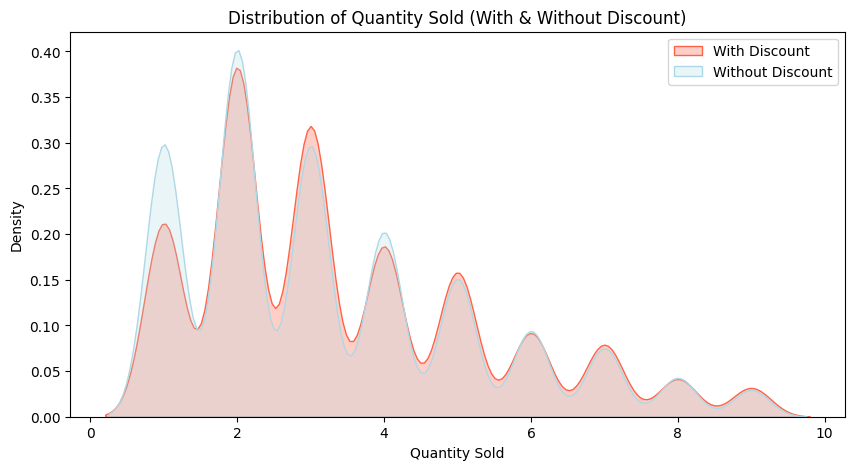

In [18]:

plt.figure(figsize=(10, 5))
sns.kdeplot(discount, label="With Discount", shade=True, color='tomato', alpha=0.3)
sns.kdeplot(not_discount, label="Without Discount", shade=True, color='lightblue')
plt.legend()
plt.title("Distribution of Quantity Sold (With & Without Discount)")
plt.xlabel("Quantity Sold")
plt.ylabel("Density")
plt.show()


In [28]:
stat, p = stats.mannwhitneyu(discount, not_discount, alternative='two-sided')

print(f"""Mann-Whitney Test:
----------------
Statistic={stat}
----------------
p-value={p}
----------------""")

alpha = 0.05
if p < alpha:
    print("Reject the null hypothesis: There is a significant difference in sales with and without discount.")
    
    if np.mean(discount) > np.mean(not_discount):
        print("Discount has a positive effect on sales.")
    else:
        print("Discount has a negative effect on sales.")
else:
    print("Fail to reject the null hypothesis: There is no significant difference in sales with and without discount.")


Mann-Whitney Test:
----------------
Statistic=415219736.5
----------------
p-value=1.3343773053079696e-28
----------------
Reject the null hypothesis: There is a significant difference in sales with and without discount.
Discount has a positive effect on sales.


<div style="direction: rtl; text-align: right;">
    تفاوت معناداری بین فروش با تخفیف و بدون تخفیف وجود دارد.همانطور که در نتیجه مشخص است تاثیر تخفیفات بر روی تعداد فروش مثب
</div>


In [27]:
stat, p = mannwhitneyu(discount, not_discount)


NameError: name 'mannwhitneyu' is not defined